In [1]:
%matplotlib widget
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from imu.SO3 import SO3
from imu.SensorUtils import SensorUtils
from imu.RotationUtils import RotationUtils
from imu.DCM import DCM
np.set_printoptions(suppress=True, precision=2)

In [2]:
data = pd.read_csv('data/imu_noise_xyz.csv')

ts = data['ts'].values/1000
euler_gt = data[['euler_x', 'euler_y', 'euler_z']].values
acc = data[['accelerometer_x', 'accelerometer_y', 'accelerometer_z']].values
mag = data[['magnetometer_x', 'magnetometer_y', 'magnetometer_z']].values
gyro = data[['gyroscope_x', 'gyroscope_y', 'gyroscope_z']].values

In [3]:
acc_si = SensorUtils.cvt_acc_si(acc) # m/s^2
mag_si = SensorUtils.cvt_mag_si(mag) # uT
gyro_si = SensorUtils.cvt_gyro_si(gyro) # rad/s
N = acc.shape[0]

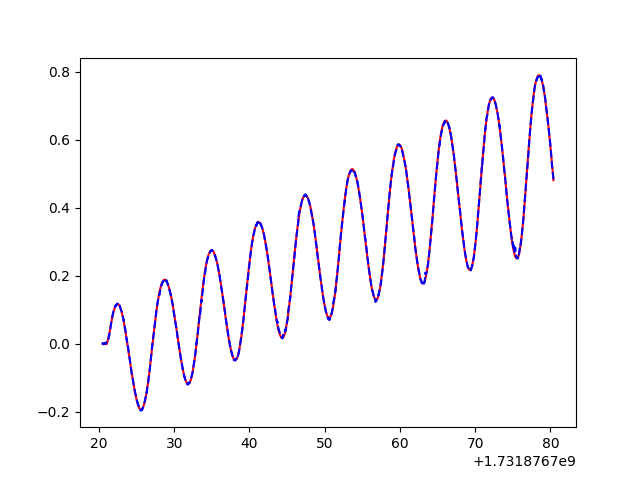

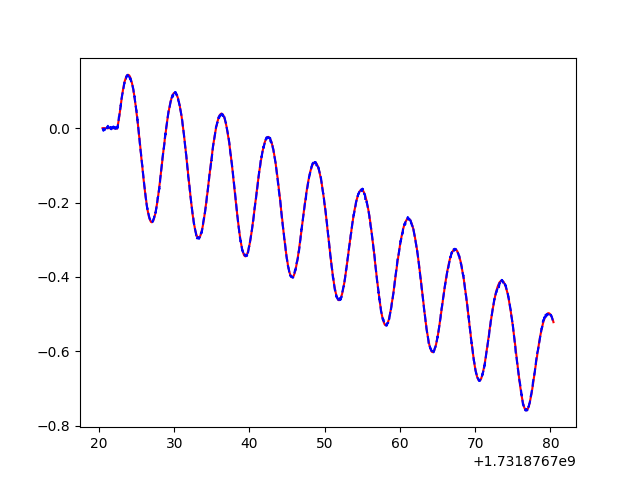

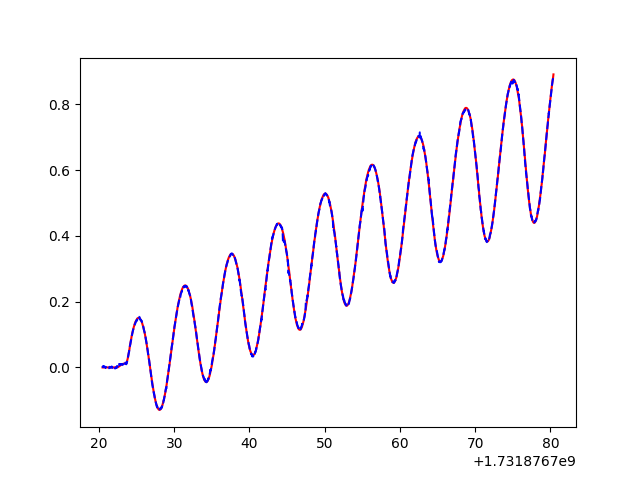

In [4]:
eul_est = np.zeros((N, 3))
dcm = DCM()
for i in range(N):
    dcm.update(gyro_si[i], acc_si[i], mag_si[i], ts[i])
    eul_est[i] = RotationUtils.rotm2eul(dcm.dcm_b2g)


plt.figure()
plt.plot(ts, euler_gt[:,0] * np.pi/180, 'r')
plt.plot(ts, eul_est[:,0], 'b--')

plt.figure()
plt.plot(ts, euler_gt[:,1] * np.pi/180, 'r')
plt.plot(ts, eul_est[:,1], 'b--')

plt.figure()
plt.plot(ts, euler_gt[:,2] * np.pi/180, 'r')
plt.plot(ts, eul_est[:,2], 'b--')


